# Technical Results Notebook

Methodological details are kept separately in `methodology.ipynb`

This notebook contains the result narrative and the code used to aggregate the result tables and plots. 

Tables and figures are generated from the analysis-ready technical outputs, with methodological cohort construction documented in `methodology.ipynb`. Some operational details were stored in text summaries rather than retaining SAM/BAM or FASTQ files, which would have been too costly.

While processing more than 1000 SRR files, many questions arose that were not included originally. Therefore, some of the analyses here are on partial data such as timing analyses. However, depending on the question, the amount of results available should still be representable enough for the side-questions that we asked along the way.

In [3]:
from pathlib import Path
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ANALYSIS = Path(".")
BASE = ANALYSIS
TECH = ANALYSIS / "technical"
DB = ANALYSIS / "srr_queue.db"

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
plt.rcParams["figure.dpi"] = 120

SUSPICIOUS_SRRS = set("""
SRR35798687 SRR35798688 SRR35798695 SRR35798696 SRR35798697 SRR35798698
SRR6334449 SRR7058572 SRR7058573 SRR7058574 SRR7058575 SRR7058576
SRR7058577 SRR7058578 SRR7058579 SRR7058580 SRR19842866 SRR17165227
""".split())
try:
    from IPython.display import display
except ImportError:
    display = print

# --- Data Source Documentation ---
# This notebook reads from the following consolidated data files:
#
# FROM ANALYSIS/ (consolidated from ja + fb pipeline runs):
#   throughput_detail.tsv    - produced by: scripts/analysis/11_compute_throughput.py
#   per_srr_eval.tsv         - produced by: scripts/analysis/02_evaluate_count_matrices.py
#   trimmomatic_detail.tsv   - produced by: scripts/analysis/03_extract_trimmomatic_stats.sh
#
# FROM ANALYSIS/technical/ (diagnostic outputs):
#   srr_quality_scores.tsv           - produced by: scripts/analysis/14_regenerate_diagnostics.py
#   current_srr_platform_check.tsv   - produced by: scripts/analysis/14_regenerate_diagnostics.py
#
# FROM DB (srr_queue.db):
#   fetch_attempts table     - populated by the pipeline during SRR downloads
#   srr_queue table          - populated by the pipeline job scheduler
#
# FROM BASE/flattened_counts/:
#   featureCounts summary files - produced by the pipeline counting step

print("Data sources:")
for label, p in [
    ("throughput_detail", ANALYSIS / "throughput_detail.tsv"),
    ("per_srr_eval", ANALYSIS / "per_srr_eval.tsv"),
    ("trimmomatic_detail", ANALYSIS / "trimmomatic_detail.tsv"),
    ("srr_quality_scores", TECH / "srr_quality_scores.tsv"),
    ("current_srr_platform_check", TECH / "current_srr_platform_check.tsv"),
    ("srr_queue.db", DB),
]:
    exists = "OK" if p.exists() else "MISSING"
    print(f"  {label:40s} [{exists}]  {p}")


Data sources:
  throughput_detail                        [OK]  throughput_detail.tsv
  per_srr_eval                             [OK]  per_srr_eval.tsv
  trimmomatic_detail                       [OK]  trimmomatic_detail.tsv
  srr_quality_scores                       [OK]  technical/srr_quality_scores.tsv
  current_srr_platform_check               [OK]  technical/current_srr_platform_check.tsv
  srr_queue.db                             [OK]  srr_queue.db


## Executive Interpretation

This technical analysis asks whether read cleaning changes downstream count profiles. Illumina RNA-seq samples were used in this assessment although not all represent standard RNA-seq analysis type processing. The answer is that cleaning does not materially change the results for adapter-only, P5, P10, and P20. These remain well aligned with the untrimmed counts. That means the technical effect of routine cleaning is small, so the biological DESeq2/GSEA follow-up is expected to be at least as stable unless a project has unusual library behavior (tbk).

Two exceptions are useful rather than contradictory. P35 is deliberately aggressive and shows the expected breakdown in read retention and count-profile similarity. It was a stress-test, not a routine cleaning choice. The non-P35 points with very high correlation loss are concentrated in `PRJNA1108066`, a miRNA-seq project that was we 'forced' through an mRNA/exon counting workflow; those points reflect a library-strategy mismatch and unstable correlations against nearly empty untrimmed count vectors. With shorter reads, random alignment became predominant.

Endpoint-download records should be interpreted cautiously. In the recorded operational attempts, ENA HTTP had the highest success rate and highest median throughput. This does not prove that Aspera is generally worse, because the endpoint attempts were sparse and unbalanced, but our own DB records do not support the older assumption that Aspera was faster and more stable in this workflow.


## 1. Download Endpoint and SRA Conversion Results

The SRR download endpoint reliability and download speed are reconstructed from the database that steered the processing on the HPC. SRA conversion is a separate local processing step, so its throughput is taken from separate records not stored in the DB. This separates network endpoint performance from post-download decompression/conversion computational costs.

In [4]:
con = sqlite3.connect(str(DB))
try:
    fetch = pd.read_sql_query("SELECT * FROM fetch_attempts", con, parse_dates=["started_at", "finished_at"])
finally:
    con.close()
fetch["duration_sec"] = (fetch["finished_at"] - fetch["started_at"]).dt.total_seconds()
fetch["mb_downloaded"] = pd.to_numeric(fetch["bytes_downloaded"], errors="coerce") / 1e6
fetch["mb_per_sec"] = fetch["mb_downloaded"] / fetch["duration_sec"]
endpoint_labels = {"aws":"AWS download", "ena_aspera":"ENA Aspera download", "ena_http":"ENA HTTP download", "gcp":"GCP download", "ncbi":"NCBI SRA download"}
data_types = {"aws":"SRA", "ena_aspera":"FASTQ.gz", "ena_http":"FASTQ.gz", "gcp":"SRA", "ncbi":"SRA"}
rows = []
for endpoint, grp in fetch.groupby("endpoint"):
    success = grp.loc[grp["status"].eq("success")].copy()
    attempts = len(grp)
    rows.append({
        "front_end_operation": endpoint_labels.get(endpoint, endpoint),
        "data_type": data_types.get(endpoint, "unknown"),
        "successes": len(success),
        "attempts": attempts,
        "failed": int(grp["status"].eq("failed").sum()),
        "cancelled": int(grp["status"].astype(str).str.contains("cancel", case=False, na=False).sum()),
        "success_pct": 100 * len(success) / attempts if attempts else np.nan,
        "median_mb_s": success["mb_per_sec"].replace([np.inf, -np.inf], np.nan).median(),
    })
endpoint_summary = pd.DataFrame(rows).sort_values("front_end_operation")
throughput = pd.read_csv(str(ANALYSIS / "throughput_detail.tsv"), sep="	")
sra_conversion = throughput.loc[(throughput["category"].eq("sra_conversion")) & (throughput["duration_sec"].ge(60))].copy()
endpoint_summary.loc[len(endpoint_summary)] = {
    "front_end_operation": "SRA conversion to .fastq.gz",
    "data_type": "SRA to FASTQ.gz",
    "successes": np.nan,
    "attempts": np.nan,
    "failed": np.nan,
    "cancelled": np.nan,
    "success_pct": np.nan,
    "median_mb_s": sra_conversion["mb_per_sec"].median(),
}
endpoint_summary


,front_end_operation,data_type,successes,attempts,failed,cancelled,success_pct,median_mb_s
0,AWS download,SRA,16.0,23.0,7.0,0.0,69.565217,5.088881
1,ENA Aspera download,FASTQ.gz,18.0,45.0,25.0,2.0,40.000000,4.965537
2,ENA HTTP download,FASTQ.gz,39.0,44.0,5.0,0.0,88.636364,7.122497
3,GCP download,SRA,9.0,14.0,5.0,0.0,64.285714,3.902241
4,NCBI SRA download,SRA,9.0,24.0,15.0,0.0,37.500000,2.722690
5,SRA conversion to .fastq.gz,SRA to FASTQ.gz,NaN,NaN,NaN,NaN,NaN,73.800000


In [5]:
# Endpoint diagnostics: the database contains only recorded fetch attempts,
# not a complete audit trail for all SRRs processed in the project.
fetch_success = fetch.loc[
    fetch["status"].eq("success")
    & fetch["duration_sec"].gt(0)
    & fetch["mb_downloaded"].gt(0)
].copy()

endpoint_distribution = fetch_success.groupby("endpoint").agg(
    speed_n=("srr_id", "size"),
    median_mb_s=("mb_per_sec", "median"),
    min_mb_s=("mb_per_sec", "min"),
    max_mb_s=("mb_per_sec", "max"),
).reset_index()
# Compute quantile and derived columns separately for pandas compatibility
endpoint_distribution["q1_mb_s"] = fetch_success.groupby("endpoint")["mb_per_sec"].quantile(0.25).values
endpoint_distribution["q3_mb_s"] = fetch_success.groupby("endpoint")["mb_per_sec"].quantile(0.75).values
endpoint_distribution["median_downloaded_gb"] = fetch_success.groupby("endpoint")["mb_downloaded"].median().values / 1000
endpoint_distribution = endpoint_distribution.sort_values("endpoint")

# Paired comparisons are sparse because endpoints were fallback attempts rather than
# a balanced benchmark where every SRR was downloaded from every endpoint.
best_success = fetch_success.sort_values("mb_per_sec", ascending=False).drop_duplicates(["srr_id", "endpoint"])
endpoint_wide = best_success.pivot(index="srr_id", columns="endpoint", values="mb_per_sec")
paired_rows = []
for a, b in [("ena_http", "ena_aspera"), ("ena_http", "aws"), ("ena_http", "gcp"), ("ena_http", "ncbi")]:
    if a not in endpoint_wide or b not in endpoint_wide:
        continue
    pair = endpoint_wide[[a, b]].dropna()
    if pair.empty:
        paired_rows.append({"comparison": f"{a} vs {b}", "paired_srrs": 0})
        continue
    diff = pair[a] - pair[b]
    paired_rows.append({
        "comparison": f"{a} vs {b}",
        "paired_srrs": len(pair),
        f"{a}_wins": int((diff > 0).sum()),
        f"{b}_wins": int((diff < 0).sum()),
        "median_mb_s_difference": diff.median(),
    })
paired_endpoint_comparison = pd.DataFrame(paired_rows)

endpoint_errors = (
    fetch.loc[fetch["status"].ne("success")]
    .fillna({"endpoint": "_NA_", "status": "_NA_", "error_msg": "_NA_"}).groupby(["endpoint", "status", "error_msg"])
    .size()
    .reset_index(name="n")
    .sort_values(["endpoint", "status", "error_msg"])
)

display(endpoint_distribution)
display(paired_endpoint_comparison)
display(endpoint_errors)


,endpoint,speed_n,median_mb_s,min_mb_s,max_mb_s,q1_mb_s,q3_mb_s,median_downloaded_gb
0,aws,16,5.088881,0.700251,11.715895,3.542870,7.140085,51.925792
1,ena_aspera,18,4.965537,3.786233,24.694498,4.576915,6.320796,68.457872
2,ena_http,39,7.122497,4.001702,24.398704,6.344173,14.009680,67.099896
3,gcp,9,3.902241,0.571936,9.528174,2.684788,5.763978,38.503409
4,ncbi,9,2.722690,0.868884,10.758400,2.399046,3.440278,57.819050


,comparison,paired_srrs,ena_http_wins,ena_aspera_wins,median_mb_s_difference,aws_wins,gcp_wins,ncbi_wins
0,ena_http vs ena_aspera,1,0,1.0,-17.638115,NaN,NaN,NaN
1,ena_http vs aws,7,6,NaN,1.212742,1.0,NaN,NaN
2,ena_http vs gcp,4,4,NaN,2.777088,NaN,0.0,NaN
3,ena_http vs ncbi,3,2,NaN,0.962125,NaN,NaN,1.0


,endpoint,status,error_msg,n
0,aws,failed,download_error,5
1,aws,failed,sra_corrupt,2
2,ena_aspera,failed,download_error,13
3,ena_aspera,failed,gzip_corrupt,2
4,ena_aspera,failed,size_mismatch,9
5,ena_aspera,failed,sra_corrupt,1
6,ena_aspera,reset_cancelled,stale_fetch_row_reconciled,2
7,ena_http,failed,download_error,4
8,ena_http,failed,size_mismatch,1
9,gcp,failed,download_error,5


### Endpoint Downloads

The recorded endpoint data do not support the earlier working assumption that Aspera was faster or more stable in this workflow. Among the recorded attempts, ENA HTTP had both the highest success rate and the highest median throughput. ENA Aspera had fewer successful transfers, more failed/cancelled attempts, and a lower median throughput than ENA HTTP.

These endpoint data are sparse and unbalanced because the pipeline used endpoint fallback rather than a controlled benchmark design. Therefore, in our operational records ENA HTTP was the most reliable and fastest endpoint overall, while the available paired data are too limited for a general network benchmark claim.


SRA files save some disk space relative to converted FASTQ.gz, but that saving comes with extra conversion cost. The following paired-size summary uses only SRRs where both SRA and converted FASTQ.gz sizes are available in the database.

In [6]:
con = sqlite3.connect(str(DB))
try:
    queue = pd.read_sql_query("SELECT project_id, srr_id, sra_size_bytes, fastq_size_bytes, size_gb FROM srr_queue", con)
finally:
    con.close()
paired_sizes = queue.dropna(subset=["sra_size_bytes", "fastq_size_bytes"]).copy()
paired_sizes = paired_sizes.loc[(paired_sizes["sra_size_bytes"] > 0) & (paired_sizes["fastq_size_bytes"] > 0)].copy()
paired_sizes["sra_gb"] = paired_sizes["sra_size_bytes"] / 1e9
paired_sizes["fastq_gb"] = paired_sizes["fastq_size_bytes"] / 1e9
paired_sizes["sra_to_fastq_ratio"] = paired_sizes["sra_size_bytes"] / paired_sizes["fastq_size_bytes"]
paired_sizes[["sra_gb", "fastq_gb", "sra_to_fastq_ratio"]].agg(["count", "median", "mean"])
summary = pd.Series({
    "n_runs_with_both_sizes": len(paired_sizes),
    "total_sra_tb": paired_sizes["sra_size_bytes"].sum() / 1e12,
    "total_fastq_tb": paired_sizes["fastq_size_bytes"].sum() / 1e12,
    "fastq_minus_sra_tb": (
        paired_sizes["fastq_size_bytes"].sum()
        - paired_sizes["sra_size_bytes"].sum()
    ) / 1e12,
    "sra_as_percent_of_fastq": (
        paired_sizes["sra_size_bytes"].sum()
        / paired_sizes["fastq_size_bytes"].sum()
        * 100
    ),
    "median_run_sra_as_percent_of_fastq": (
        paired_sizes["sra_to_fastq_ratio"].median() * 100
    ),
})
summary

n_runs_with_both_sizes                61.000000
total_sra_tb                           2.600649
total_fastq_tb                         2.714054
fastq_minus_sra_tb                     0.113405
sra_as_percent_of_fastq               95.821567
median_run_sra_as_percent_of_fastq    85.143400
dtype: float64

### Download and SRA Conversion

The endpoint table separates network retrieval from local SRA conversion. Direct FASTQ.gz retrieval avoids the SRA conversion step, whereas SRA-producing endpoints require local conversion/decompression before the same processing workflow can begin.

From a computational-cost perspective, SRA was less attractive than direct FASTQ.gz retrieval for this analysis. In the paired-size subset, SRA saved a minuite amount of disk space relative to converted FASTQ.gz, but the saving came with an additional conversion step, extra scheduling complexity, and substantial core-hour use. At the observed conversion throughput, SRA conversion is not a trivial pre-processing detail; it is a meaningful compute cost that has to be accounted for when scaling to hundreds or thousands of SRRs. The compute cost equals that of the bowtie2 alignment step.

The practical result is that direct FASTQ.gz availability is preferable for this kind of large technical benchmark. SRA is useful as an archival format, but if SRA-side services also exposed ready-to-use `.fastq.gz` files consistently, workflows like this would spend less cluster time on conversion and more time on the actual analysis. Considering the very small space saving we observed, SRA should be avoided.


## 2. Processing Cost

Processing cost is recorded on a per step basis, e.g., for FastQC analysis. The time and the amount of cores used is recorded for several hundred of the analyses done in this project. The six different trimming - alignment - counting branches are however not comparable among the branches becahse different settings were used and for p35 this becomes especially obvious. Among SRR files the comparison of the same branches is of course possible. 



In [7]:
throughput = pd.read_csv(str(ANALYSIS / "throughput_detail.tsv"), sep="\t")
for col in ["duration_sec", "cores_used", "total_reads_M", "fastq_mb"]:
    throughput[col] = pd.to_numeric(throughput[col], errors="coerce")

# ---- Filter: keep only SRRs whose timings were recorded in a single Slurm job ----
# The pipeline uses checkpointing; when a job was re-run, different modes could be
# processed in separate Slurm jobs on different nodes.  The backfill script
# (12_backfill_flattened_stats_from_logs.py) assembled those into one timing file
# but set start_epoch = 0.  Files with real non-zero start_epoch had all stages
# in the same job — only those give valid cross-mode comparisons.
_timing_base = (ANALYSIS / ".." / "flattened_timings").resolve()
_real_srrs = set()
if _timing_base.is_dir():
    for _proj in sorted(_timing_base.iterdir()):
        if not _proj.is_dir():
            continue
        for _tf in _proj.glob("*_timings.tsv"):
            try:
                _tdf = pd.read_csv(str(_tf), sep="\t")
                if "start_epoch" not in _tdf.columns:
                    continue
                _stage_rows = _tdf[_tdf["stage"].str.match(
                    r"^(trim_|align_|count_|mode_|fastqc|sra_conversion|pipeline_total|eval_modes)", na=False
                )]
                if len(_stage_rows) == 0:
                    continue
                _se = _stage_rows["start_epoch"].dropna()
                if len(_se) > 0 and not (_se == 0).all():
                    _real_srrs.add(_tf.stem.replace("_timings", ""))
            except Exception:
                pass
    n_before = throughput["SRR_ID"].nunique()
    throughput = throughput.loc[throughput["SRR_ID"].isin(_real_srrs)].copy()
    print(f"Filtered to {throughput['SRR_ID'].nunique()} / {n_before} SRRs with same-job timings")
else:
    print(f"WARNING: {_timing_base} not found; using all data (may include cross-job timings)")

throughput["core_seconds"] = throughput["duration_sec"] * throughput["cores_used"]
# Cap FastQC at 2 effective cores based on benchmarks
throughput.loc[throughput["stage"].eq("fastqc"), "core_seconds"] = throughput.loc[throughput["stage"].eq("fastqc"), "duration_sec"] * 2
throughput["cpu_hours"] = throughput["core_seconds"] / 3600
throughput["fastq_gb"] = throughput["fastq_mb"] / 1024
throughput["cpu_hours_per_gb"] = throughput["cpu_hours"] / throughput["fastq_gb"]

# Also compute core_hours_per_gb (alias used by some downstream cells)
throughput["core_hours_per_gb"] = throughput["cpu_hours_per_gb"]

align_modes = ["untrimmed", "adapter_only", "P5", "P10", "P20", "P35"]
stage_order = ["fastqc", "sra_conversion"] + [f"{prefix}_{mode}" for mode in align_modes for prefix in ["trim", "align", "count"]]
stage_order = [stage for stage in stage_order if throughput["stage"].eq(stage).any()]

# Summary table
_valid = throughput.loc[
    throughput["stage"].isin(stage_order)
    & throughput["cpu_hours_per_gb"].notna()
    & throughput["cpu_hours_per_gb"].replace([np.inf, -np.inf], np.nan).notna()
].copy()
stage_cost = _valid.groupby(["category", "stage", "mode"]).agg(
    records=("cpu_hours_per_gb", "size"),
    median_cpu_h_per_gb=("cpu_hours_per_gb", "median"),
    median_core_seconds=("core_seconds", "median"),
    median_cpu_hours=("cpu_hours", "median"),
).reset_index()
stage_cost["q1_cpu_h_per_gb"] = _valid.groupby(["category", "stage", "mode"])["cpu_hours_per_gb"].quantile(0.25).values
stage_cost["q3_cpu_h_per_gb"] = _valid.groupby(["category", "stage", "mode"])["cpu_hours_per_gb"].quantile(0.75).values
stage_cost["stage"] = pd.Categorical(stage_cost["stage"], categories=stage_order, ordered=True)
stage_cost = stage_cost.sort_values("stage")
stage_cost


In [8]:
from matplotlib.patches import Patch

# Filter to valid core_hours_per_gb values
valid_throughput = throughput.loc[
    throughput["core_hours_per_gb"].notna()
    & throughput["core_hours_per_gb"].replace([np.inf, -np.inf], np.nan).notna()
    & throughput["core_hours_per_gb"].gt(0)
].copy()

plot_data = []
labels = []
for stage in stage_order:
    vals = valid_throughput.loc[valid_throughput["stage"].eq(stage), "core_hours_per_gb"].dropna()
    vals = vals.loc[vals.gt(0)]
    if len(vals):
        plot_data.append(vals.to_numpy())
        labels.append(stage.replace("_", "\n"))

print(f"Data points: {sum(len(v) for v in plot_data)}, SRRs: {valid_throughput['SRR_ID'].nunique()} (same-job timings)")

fig, ax = plt.subplots(figsize=(20, 8))
bp = ax.boxplot(plot_data, tick_labels=labels, patch_artist=True, notch=True,
                widths=0.55, showfliers=True,
                flierprops=dict(marker="o", markersize=4, alpha=0.4, markerfacecolor="#555"),
                medianprops=dict(color="#222", linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2))
cat_colors = {"fastqc": "#64B5F6", "sra": "#90A4AE", "trim": "#81C784", "align": "#FFB74D", "count": "#BA68C8"}
for i, label_text in enumerate(labels):
    flat = label_text.replace("\n", "_")
    if flat.startswith("trim"):
        color = cat_colors["trim"]
    elif flat.startswith("align"):
        color = cat_colors["align"]
    elif flat.startswith("count"):
        color = cat_colors["count"]
    elif flat.startswith("fastqc"):
        color = cat_colors["fastqc"]
    else:
        color = cat_colors["sra"]
    bp["boxes"][i].set_facecolor(color)
    bp["boxes"][i].set_alpha(0.85)
    bp["boxes"][i].set_edgecolor("#444")
    bp["boxes"][i].set_linewidth(1.2)

ax.set_ylabel("core-hours per GB FASTQ input", fontsize=16, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=13)
ax.tick_params(axis="y", labelsize=13)
ax.grid(axis="y", alpha=0.3, linewidth=0.8)
ax.set_yscale("log")
ax.legend(handles=[
    Patch(facecolor="#64B5F6", alpha=0.85, edgecolor="#444", linewidth=1.2, label="FastQC (2 cores eff.)"),
    Patch(facecolor="#90A4AE", alpha=0.85, edgecolor="#444", linewidth=1.2, label="SRA conversion (36 cores)"),
    Patch(facecolor="#81C784", alpha=0.85, edgecolor="#444", linewidth=1.2, label="Trimming (36 cores)"),
    Patch(facecolor="#FFB74D", alpha=0.85, edgecolor="#444", linewidth=1.2, label="Alignment (36 cores)"),
    Patch(facecolor="#BA68C8", alpha=0.85, edgecolor="#444", linewidth=1.2, label="Counting (36 cores)"),
], loc="upper right", fontsize=13, framealpha=0.9)
fig.tight_layout()
plt.show()


### Processing Cost

The stage-cost plot should be read as the cost of the benchmark matrix, not as the cost of a single normal RNA-seq analysis. A normal analysis would run FastQC, one trimming choice, one alignment, and one counting step. Here, the repeated cleaning/alignment/counting branches were run to test whether cleaning changes the count profile, so the computational cost is intentionally multiplied by the experimental design.

Translated back to a standard one-pass RNA-seq workflow, FastQC plus one trimming mode is not negligible. One Bowtie2 alignment costs roughly the same order of compute as FastQC plus one trimming pass, while counting is neglegible by comparison. This matters for interpretation: cleaning itself is not free and together with quality check adds a significant amount of compute. When running other aligners such as STAR, this could be much more cost for QC and trimming than for alignment.

Considering the SRA conversion, it added as much computational cost as the bowtie2 alignment. 


## 3. Count-profile Stability Results

For each SRR and cleaning mode, the cleaned count vector is compared against the untrimmed count vector. Pearson correlation captures linear count-vector similarity, while Jensen-Shannon divergence captures distributional change.

In [9]:
eval_df = pd.read_csv(str(ANALYSIS / "per_srr_eval.tsv"), sep="	")
mode_map = {
    "Adapter": ("untrmd_adptrTrmd_pear", "untrmd_adptrTrmd_jsd"),
    "P5": ("untrmd_P5Trmd_pear", "untrmd_P5Trmd_jsd"),
    "P10": ("untrmd_P10Trmd_pear", "untrmd_P10Trmd_jsd"),
    "P20": ("untrmd_P20Trmd_pear", "untrmd_P20Trmd_jsd"),
    "P35": ("untrmd_P35Trmd_pear", "untrmd_P35Trmd_jsd"),
}
count_stability = pd.DataFrame([
    {
        "mode": mode,
        "srrs_with_values": len(eval_df[[pear_col, jsd_col]].dropna()),
        "median_pearson_r": eval_df[pear_col].median(skipna=True),
        "median_jsd": eval_df[jsd_col].median(skipna=True),
    }
    for mode, (pear_col, jsd_col) in mode_map.items()
])
count_stability

,mode,srrs_with_values,median_pearson_r,median_jsd
0,Adapter,1125,1.000000,0.000004
1,P5,1125,0.999998,0.000011
2,P10,1125,0.999996,0.000022
3,P20,1125,0.999869,0.000424
4,P35,395,0.982893,0.041328


Data points used for plot: 1125


/var/folders/lw/lj39y98919j8mslvy2vtmqbm0000gn/T/ipykernel_34934/480595904.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([eval_df[pear_col].dropna() for pear_col, _ in mode_map.values()], labels=list(mode_map.keys()), showfliers=False)


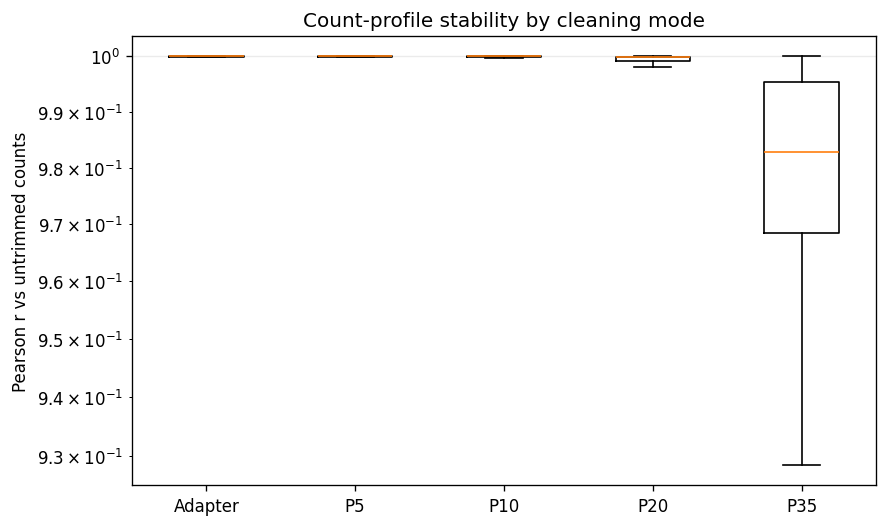

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
print(f"Data points used for plot: {len(eval_df.dropna(subset=[col for col, _ in mode_map.values()], how='all'))}")
ax.boxplot([eval_df[pear_col].dropna() for pear_col, _ in mode_map.values()], labels=list(mode_map.keys()), showfliers=False)
ax.set_ylabel("Pearson r vs untrimmed counts")
ax.set_title("Count-profile stability by cleaning mode")
ax.grid(axis="y", alpha=0.25)
ax.set_yscale("log")
fig.tight_layout()
plt.show()

### Interpretation: Count-profile Stability

The count-profile comparison is the core technical result. Across the Illumina assessment set, adapter-only, P5, P10, and P20 cleaning remain well aligned with the untrimmed count vectors for most SRRs. This supports the central view from the executive summary: routine cleaning does not materially change the count profiles in the datasets where the mRNA-style counting workflow is appropriate.

This statement is intentionally about routine cleaning and count-profile stability, not about every dataset being an ideal standard RNA-seq experiment. Some projects enter the broad transcriptomic filter but behave differently because the library type or read structure is not well matched to exon-level mRNA counting. Those cases are handled as interpretation caveats rather than as evidence that ordinary cleaning is unstable.

P35 is deliberately aggressive and behaves as the stress-test case where cleaning can damage the count profile. It should be retained as a stress test but excluded from the main practical cleaning recommendation.


## 4. Read-retention Results

Read retention is evaluated from all available mode-resolved Trimmomatic summaries. Read retention is evaluated from the consolidated `trimmomatic_detail.tsv` table produced by `03_extract_trimmomatic_stats.sh`, which aggregates all per-SRR flattened Trimmomatic stats from `flattened_trimmomatic_stats/`. This includes both originally processed (ja) and student-processed (fb) data after integration.


In [11]:
trim = pd.read_csv(str(ANALYSIS / "trimmomatic_detail.tsv"), sep="\t")
# Use the consolidated trimmomatic stats natively!
if "SRR_ID" in trim.columns:
    trim = trim.rename(columns={"SRR_ID": "srr_id"})
trim["surviving_pct"] = pd.to_numeric(trim["surviving_pct"], errors="coerce")
trim_modes = ["adapter_only", "P5", "P10", "P20", "P35"]
wide_trim = trim.loc[trim["mode"].isin(trim_modes)].pivot_table(
    index=["project_id", "srr_id"], columns="mode", values="surviving_pct", aggfunc="mean"
)
paired_trim_practical = wide_trim.dropna(subset=["adapter_only", "P5", "P10", "P20"])
paired_trim_all_modes = wide_trim.dropna(subset=trim_modes)

retention_coverage = pd.DataFrame({
    "source_or_subset": [
        "flattened trimmomatic stats (all projects)",
        "combined mode-resolved table, any mode",
        "combined with adapter/P5/P10/P20",
        "combined with adapter/P5/P10/P20/P35",
    ],
    "count": [
        len(trim),
        wide_trim.shape[0],
        paired_trim_practical.shape[0],
        paired_trim_all_modes.shape[0],
    ],
})

read_retention = pd.DataFrame([
    {
        "mode": mode,
        "srrs_with_mode": int(wide_trim[mode].notna().sum()),
        "paired_all_modes_srrs": len(paired_trim_all_modes),
        "median_surviving_pct": wide_trim[mode].median(),
        "mean_surviving_pct": wide_trim[mode].mean(),
        #"q1_surviving_pct": wide_trim[mode].quantile(0.25),
        #"q3_surviving_pct": wide_trim[mode].quantile(0.75),
        #"min_surviving_pct": wide_trim[mode].min(),
        #"max_surviving_pct": wide_trim[mode].max(),
    }
    for mode in trim_modes
])

display(retention_coverage)
display(read_retention)


,source_or_subset,count
0,flattened trimmomatic stats (all projects),5266
1,"combined mode-resolved table, any mode",1126
2,combined with adapter/P5/P10/P20,1002
3,combined with adapter/P5/P10/P20/P35,990


,mode,srrs_with_mode,paired_all_modes_srrs,median_surviving_pct,mean_surviving_pct
0,adapter_only,1119,990,100.00,98.473566
1,P5,1025,990,99.98,99.578663
2,P10,1023,990,99.98,99.375474
3,P20,1025,990,99.89,98.850722
4,P35,1074,990,0.00,26.562523


/var/folders/lw/lj39y98919j8mslvy2vtmqbm0000gn/T/ipykernel_34934/2886054917.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


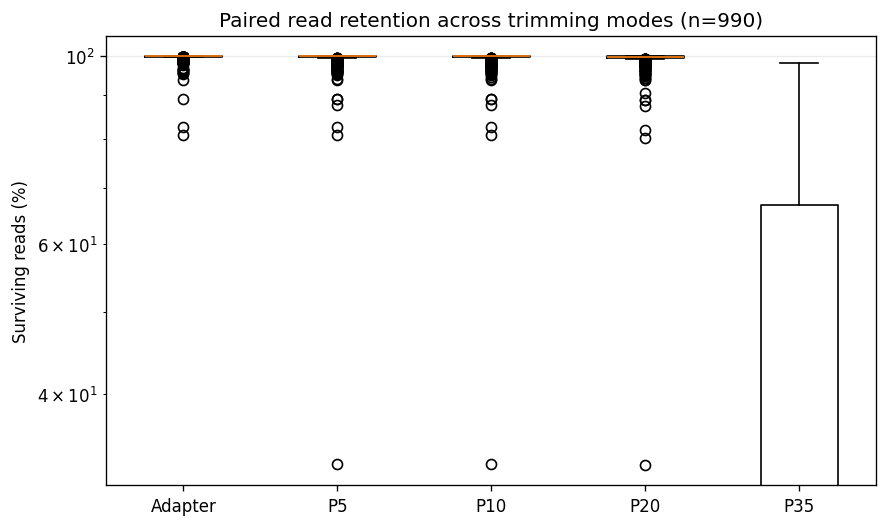

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.boxplot(
    [paired_trim_all_modes[mode].dropna() for mode in trim_modes],
    labels=["Adapter", "P5", "P10", "P20", "P35"],
    showfliers=True,
)
ax.set_ylabel("Surviving reads (%)")
ax.set_title(f"Paired read retention across trimming modes (n={len(paired_trim_all_modes)})")
ax.grid(axis="y", alpha=0.25)
ax.set_yscale("log")
fig.tight_layout()
plt.show()


### Interpretation: Read Retention

Read retention data is sourced from the consolidated `trimmomatic_detail.tsv`, which contains all mode-resolved Trimmomatic summary records from both the primary (ja) and student (fb) processing runs after integration into `flattened_trimmomatic_stats/`. Adapter/P5/P10/P20 retain nearly all reads for most SRRs. P35 remains the clear aggressive stress-test condition and is not comparable to routine cleaning modes.


## 5. Integrated Quality Sensitivity Results

The integrated quality view combines `srr_quality_scores.tsv` with count-profile metrics. Suspicious SRRs are excluded. The terminal mean quality metric prefers flattened FastQC raw output when available and falls back to MultiQC per-base quality otherwise.

In [13]:
trimmomatic = pd.read_csv(str(ANALYSIS / "trimmomatic_detail.tsv"), sep="\t")
for c in ["input_reads", "dropped"]:
    trimmomatic[c] = pd.to_numeric(trimmomatic[c], errors="coerce")
trimmomatic["dropped_per_million"] = (trimmomatic["dropped"] / trimmomatic["input_reads"]) * 1e6

quality = pd.read_csv(str(TECH / "srr_quality_scores.tsv"), sep="\t")

merged = eval_df.merge(quality, on="SRR_ID", how="inner", suffixes=("", "_quality"))

# Compute avg_mean_q right away so it is available
merged["avg_mean_q"] = pd.to_numeric(
    merged.get("fastqc_raw_per_base_mean_q_mean", pd.Series(dtype=float)), errors="coerce"
).combine_first(
    pd.to_numeric(merged.get("multiqc_per_base_per_base_mean_q_mean", pd.Series(dtype=float)), errors="coerce")
)

# Use non-P35 modes as the primary set so we keep ~1134 SRRs instead of ~465
pear_cols = {
    "Adapter": "untrmd_adptrTrmd_pear",
    "P5": "untrmd_P5Trmd_pear",
    "P10": "untrmd_P10Trmd_pear",
    "P20": "untrmd_P20Trmd_pear",
}
pear_cols_with_p35 = {**pear_cols, "P35": "untrmd_P35Trmd_pear"}

for col in list(pear_cols_with_p35.values()) + ["fastqc_raw_tail10_mean_q", "multiqc_per_base_tail10_mean_q", "fastqc_raw_read_length_end", "multiqc_per_base_read_length_end"]:
    merged[col] = pd.to_numeric(merged[col], errors="coerce")
merged["terminal_mean_q"] = merged["fastqc_raw_tail10_mean_q"].combine_first(merged["multiqc_per_base_tail10_mean_q"])
merged["read_length_end"] = merged["fastqc_raw_read_length_end"].combine_first(merged["multiqc_per_base_read_length_end"])
merged = merged.loc[~merged["SRR_ID"].isin(SUSPICIOUS_SRRS)].copy()

# Require all 4 non-P35 modes + quality; P35 is optional
required_cols = list(pear_cols.values()) + ["terminal_mean_q", "read_length_end"]
merged = merged.dropna(subset=required_cols)

def read_length_bucket(x):
    if x <= 85:
        return "<=85 bp"
    if x <= 100:
        return "86-100 bp"
    if x <= 150:
        return "101-150 bp"
    return ">150 bp" 

merged["read_length_bucket"] = merged["read_length_end"].map(read_length_bucket)

# Build integrated table with all available modes (P35 where present)
parts = []
for mode, col in pear_cols_with_p35.items():
    sub = merged.loc[merged[col].notna()].copy()
    part = sub[["SRR_ID", "project_id", "terminal_mean_q", "avg_mean_q", "read_length_end", "read_length_bucket", col]].rename(columns={col: "pearson"}).copy()
    # Map 'Adapter' to 'adapter_only' to match trimmomatic stats
    part["cleaning_mode"] = "adapter_only" if mode == "Adapter" else mode
    part["correlation_loss"] = 1.0 - part["pearson"]
    parts.append(part)
integrated_tail = pd.concat(parts, ignore_index=True)

# Merge dropped reads into integrated_tail
integrated_tail = integrated_tail.merge(trimmomatic[["SRR_ID", "mode", "dropped_per_million"]], left_on=["SRR_ID", "cleaning_mode"], right_on=["SRR_ID", "mode"], how="left")

quality_summary = merged.groupby("read_length_bucket")["terminal_mean_q"].agg(["count", "min", "median", "max"]).reset_index()
n_with_p35 = merged["untrmd_P35Trmd_pear"].notna().sum()
print(f"SRRs with Adapter/P5/P10/P20 + quality: {len(merged)}")
print(f"SRRs also with P35: {n_with_p35}")
print(f"Mode-specific points: {len(integrated_tail)}")
display(quality_summary)

SRRs with Adapter/P5/P10/P20 + quality: 1125
SRRs also with P35: 395
Mode-specific points: 4895


,read_length_bucket,count,min,median,max
0,101-150 bp,389,22.3901,35.30170,40.1224
1,86-100 bp,364,17.9499,33.22410,39.6341
2,<=85 bp,292,26.6343,36.83380,40.0603
3,>150 bp,80,19.5341,33.15685,38.8856


/var/folders/lw/lj39y98919j8mslvy2vtmqbm0000gn/T/ipykernel_34934/2587123849.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([str(abs(int(y))) for y in yticks])


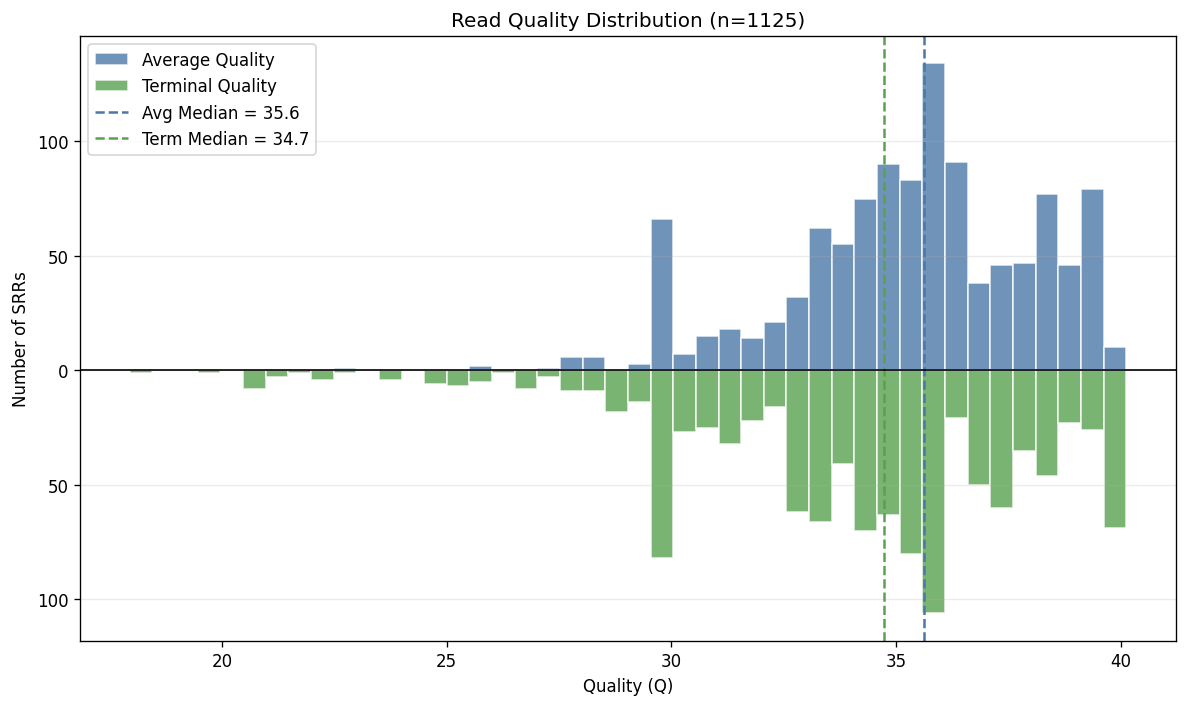

Average quality:  n=1125, median=35.62, min=22.55, max=39.80
Terminal quality: n=1125, median=34.72, min=17.95, max=40.12


In [14]:
# Quality distribution overview: average vs terminal read quality
merged["avg_mean_q"] = pd.to_numeric(
    merged.get("fastqc_raw_per_base_mean_q_mean", pd.Series(dtype=float)), errors="coerce"
).combine_first(
    pd.to_numeric(merged.get("multiqc_per_base_per_base_mean_q_mean", pd.Series(dtype=float)), errors="coerce")
)

avg_q = merged["avg_mean_q"].dropna()
term_q = merged["terminal_mean_q"].dropna()

fig, ax = plt.subplots(figsize=(10, 6))

bins = np.linspace(min(avg_q.min(), term_q.min()), max(avg_q.max(), term_q.max()), 45)

# Top histogram (Average quality)
ax.hist(avg_q, bins=bins, color="#4C78A8", alpha=0.8, edgecolor="white", label="Average Quality")

# Bottom histogram (Terminal quality) - we negate the weights
ax.hist(term_q, bins=bins, weights=-np.ones_like(term_q), color="#59A14F", alpha=0.8, edgecolor="white", label="Terminal Quality")

# Add median lines
ax.axvline(avg_q.median(), color="#4C78A8", linestyle="--", linewidth=1.5, label=f"Avg Median = {avg_q.median():.1f}")
ax.axvline(term_q.median(), color="#59A14F", linestyle="--", linewidth=1.5, label=f"Term Median = {term_q.median():.1f}")

# Adjust y-axis to show positive labels for both sides
yticks = ax.get_yticks()
ax.set_yticklabels([str(abs(int(y))) for y in yticks])

ax.set_xlabel("Quality (Q)")
ax.set_ylabel("Number of SRRs")
ax.set_title(f"Read Quality Distribution (n={len(avg_q)})")
ax.legend(loc='upper left')
ax.grid(axis="y", alpha=0.25)
ax.axhline(0, color='black', linewidth=1) # Center line

fig.tight_layout()
plt.show()

print(f"Average quality:  n={len(avg_q)}, median={avg_q.median():.2f}, min={avg_q.min():.2f}, max={avg_q.max():.2f}")
print(f"Terminal quality: n={len(term_q)}, median={term_q.median():.2f}, min={term_q.min():.2f}, max={term_q.max():.2f}")

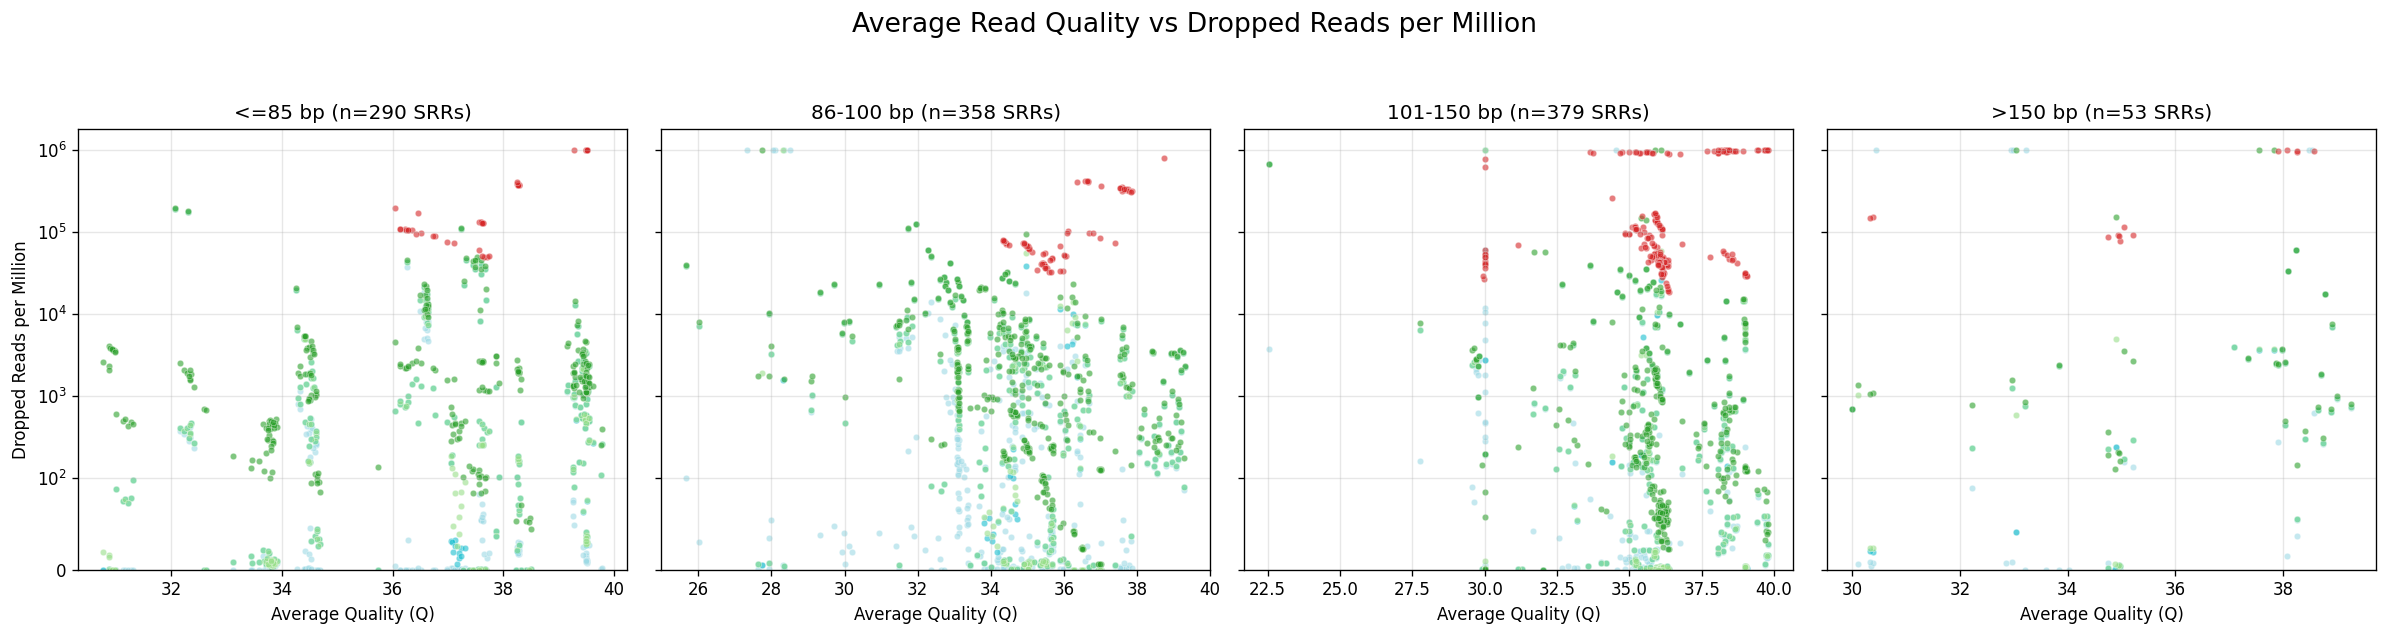

In [15]:
# Dropped reads vs quality for each read length bin
buckets = ["<=85 bp", "86-100 bp", "101-150 bp", ">150 bp"]
modes = ["adapter_only", "P5", "P10", "P20", "P35"]
mode_colors = {"adapter_only": "#9edae5", "P5": "#17becf", "P10": "#98df8a", "P20": "#2ca02c", "P35": "#d62728"}

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, bucket in zip(axes, buckets):
    sub_bucket = integrated_tail.loc[integrated_tail["read_length_bucket"] == bucket].dropna(subset=["avg_mean_q", "dropped_per_million"])
    if len(sub_bucket) == 0:
        ax.set_title(f"{bucket}\n(No data)")
        continue
        
    for mode in modes:
        sub_mode = sub_bucket[sub_bucket["cleaning_mode"] == mode]
        if len(sub_mode) > 0:
            ax.scatter(sub_mode["avg_mean_q"], sub_mode["dropped_per_million"], label=mode,
                       color=mode_colors[mode], alpha=0.6, s=15, edgecolor="white", linewidth=0.3)
    
    n_srr = sub_bucket["SRR_ID"].nunique()
    ax.set_title(f"{bucket} (n={n_srr} SRRs)")
    ax.set_xlabel("Average Quality (Q)")
    ax.grid(alpha=0.3)
    if bucket == "<75 bp":  # Only show legend on first plot
        ax.legend(title="Trimming Mode", loc="upper right")

axes[0].set_ylabel("Dropped Reads per Million")
axes[0].set_yscale("symlog", linthresh=100)
axes[0].set_ylim(bottom=0)
fig.suptitle("Average Read Quality vs Dropped Reads per Million", fontsize=16, y=1.05)
fig.tight_layout()
plt.show()

Data points used for plot: 4895


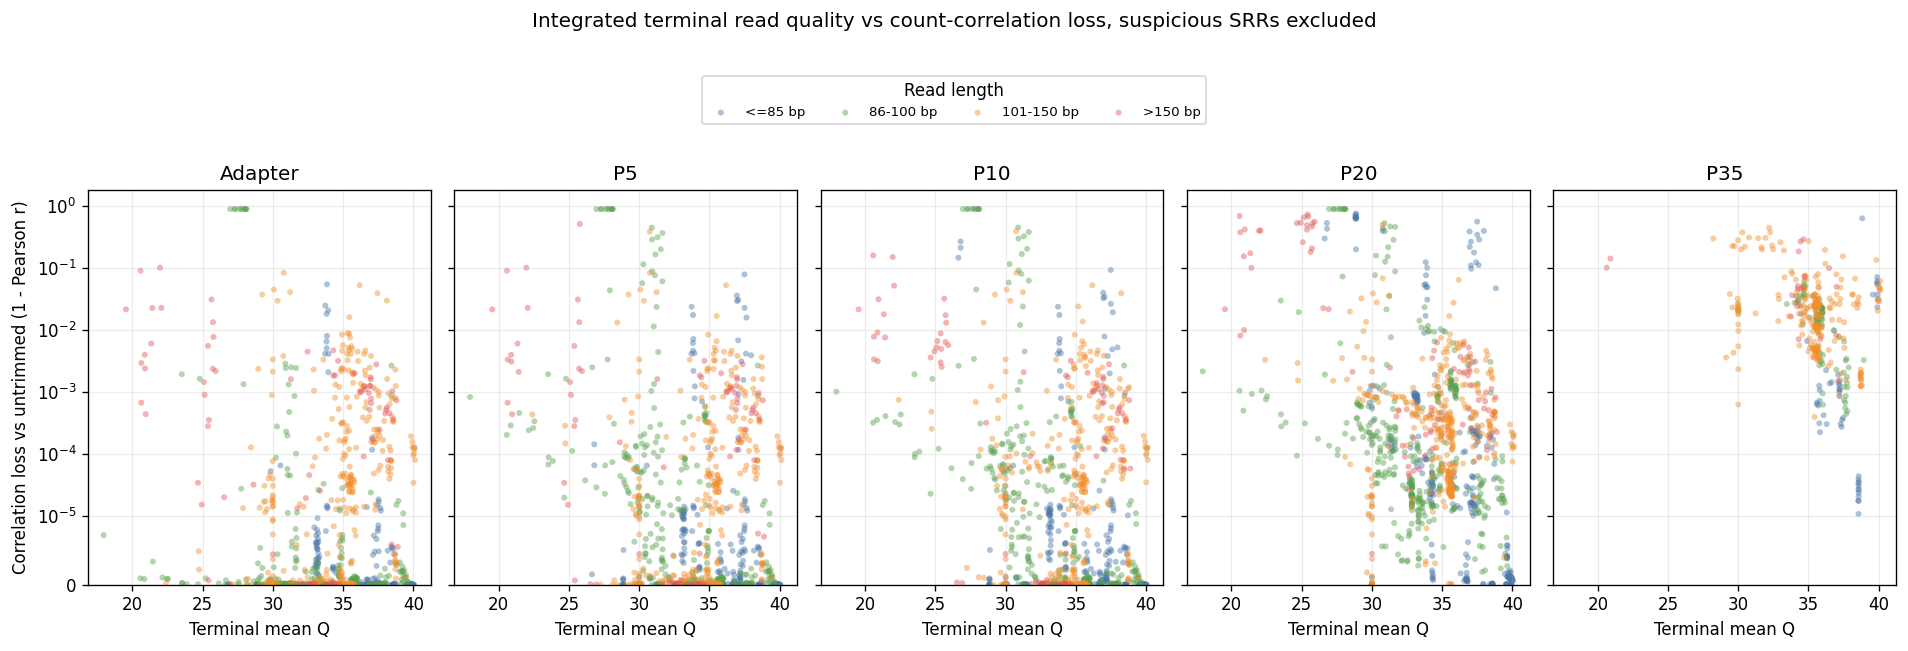

In [16]:
colors = {"<=85 bp": "#4C78A8", "86-100 bp": "#59A14F", "101-150 bp": "#F28E2B", ">150 bp": "#E15759"}
print(f"Data points used for plot: {len(integrated_tail)}")
fig, axes = plt.subplots(1, 5, figsize=(16, 4.8), sharex=True, sharey=True)
modes = ["adapter_only", "P5", "P10", "P20", "P35"]
for ax, mode in zip(axes, modes):
    sub = integrated_tail.loc[integrated_tail["cleaning_mode"].eq(mode)]
    for bucket, color in colors.items():
        ss = sub.loc[sub["read_length_bucket"].eq(bucket)]
        ax.scatter(ss["terminal_mean_q"], ss["correlation_loss"], s=13, alpha=0.45, color=color, label=bucket, edgecolors="none")
    ax.set_title("Adapter" if mode == "adapter_only" else mode)
    ax.set_yscale("symlog", linthresh=1e-5)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.22)
    ax.set_xlabel("Terminal mean Q")
axes[0].set_ylabel("Correlation loss vs untrimmed (1 - Pearson r)")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, title="Read length", loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.02), fontsize=8)
fig.suptitle("Integrated terminal read quality vs count-correlation loss, suspicious SRRs excluded", y=1.12)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()


Data points used for plot: 4895


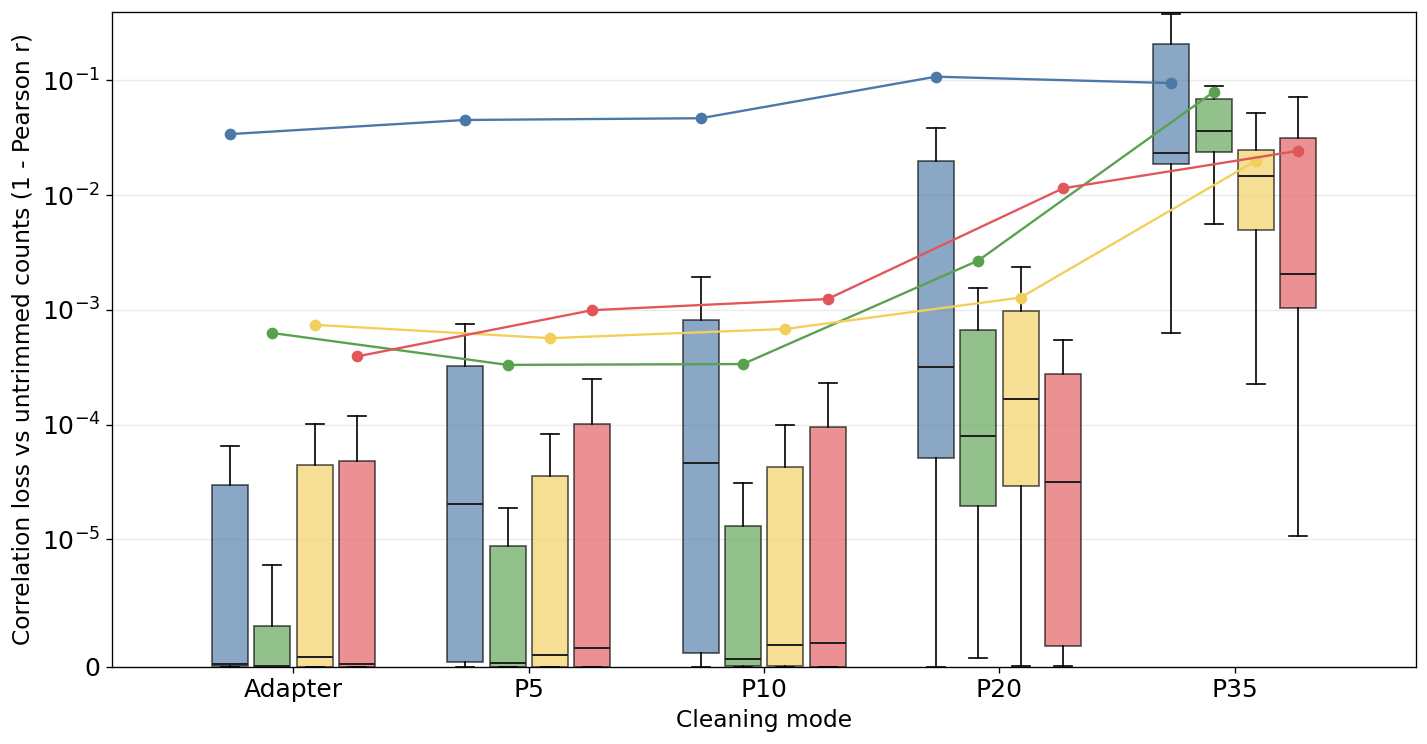

In [28]:
srr_bins = integrated_tail[["SRR_ID", "terminal_mean_q"]].drop_duplicates().copy()
srr_bins["terminal_quality_bin"] = pd.qcut(srr_bins["terminal_mean_q"], q=4, duplicates="drop")
plot_df = integrated_tail.merge(srr_bins[["SRR_ID", "terminal_quality_bin"]], on="SRR_ID")
modes = ["adapter_only", "P5", "P10", "P20", "P35"]
bins = list(plot_df["terminal_quality_bin"].cat.categories)
x = np.arange(len(modes))
width = min(0.18, 0.75 / len(bins))
palette = ["#4C78A8", "#59A14F", "#F2CF5B", "#E15759"]
print(f"Data points used for plot: {len(plot_df)}")
fig, ax = plt.subplots(figsize=(12, 6.3))
for i, bin_label in enumerate(bins):
    vals = [plot_df.loc[(plot_df["terminal_quality_bin"].eq(bin_label)) & (plot_df["cleaning_mode"].eq(mode)), "correlation_loss"].dropna() for mode in modes]
    pos = x + (i - (len(bins) - 1) / 2) * width
    bp = ax.boxplot(vals, positions=pos, widths=width * 0.85, patch_artist=True, showfliers=False)
    for patch in bp["boxes"]:
        patch.set_facecolor(palette[i % len(palette)])
        patch.set_alpha(0.65)
    for med in bp["medians"]:
        med.set_color("#222222")
        med.set_linewidth(1.2)
    means = [v.mean() if len(v) else np.nan for v in vals]
    label = f"{bin_label.left:.1f}-{bin_label.right:.1f} (n={srr_bins['terminal_quality_bin'].eq(bin_label).sum()})"
    ax.plot(pos, means, marker="o", linewidth=1.4, color=palette[i % len(palette)], label=label)
ax.set_xticks(x)
ax.set_xticklabels(["Adapter" if m == "adapter_only" else m for m in modes])
ax.set_yscale("symlog", linthresh=1e-5)
ax.set_ylim(bottom=0)

ax.set_ylabel("Correlation loss vs untrimmed counts (1 - Pearson r)", fontsize=14)
ax.set_xlabel("Cleaning mode", fontsize=14)
#ax.set_title("Integrated terminal read quality bins vs count-correlation loss, suspicious SRRs excluded")
ax.grid(axis="y", alpha=0.25)

ax.tick_params(axis="x", labelsize=15)
ax.tick_params(axis="y", labelsize=15)
fig.tight_layout()
plt.show()

### Spearman Correlation Integrated Quality Plot

Data points used for plot: 4895


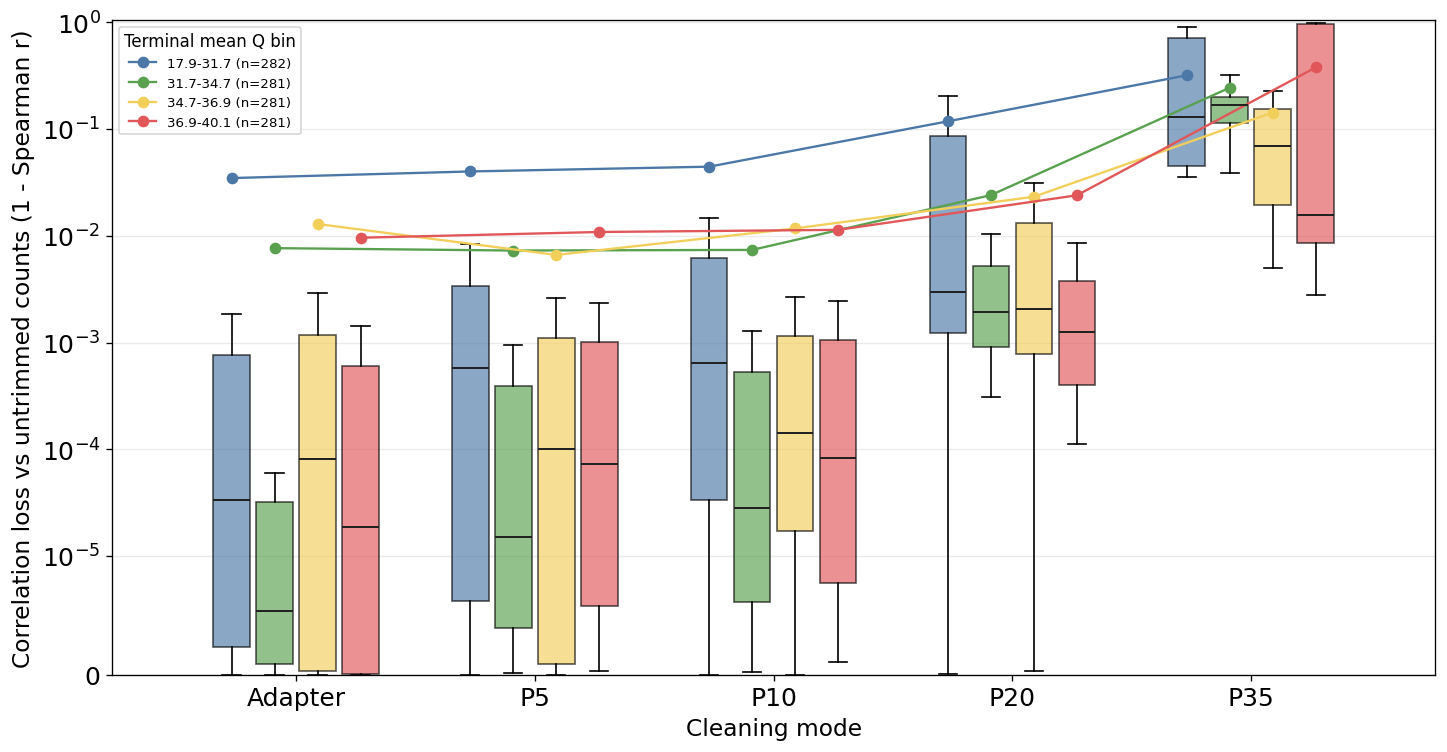

In [30]:
# Create a Spearman version of the plot
spear_cols_with_p35 = {
    "Adapter": "untrmd_adptrTrmd_spear",
    "P5": "untrmd_P5Trmd_spear",
    "P10": "untrmd_P10Trmd_spear",
    "P20": "untrmd_P20Trmd_spear",
    "P35": "untrmd_P35Trmd_spear",
}

# Reload the eval data to ensure we have the latest spearman columns
latest_eval = pd.read_csv(ANALYSIS / "per_srr_eval.tsv", sep="\t")

spear_parts = []
for mode, col in spear_cols_with_p35.items():
    clean_mode = "adapter_only" if mode == "Adapter" else mode
    # Join the latest metric with integrated_tail which already has quality bins and filters
    sub = integrated_tail.loc[integrated_tail["cleaning_mode"] == clean_mode].copy()
    sub = sub.merge(latest_eval[["SRR_ID", col]], on="SRR_ID", how="inner")
    
    sub[col] = pd.to_numeric(sub[col], errors='coerce')
    sub = sub.dropna(subset=[col])
    
    sub["spearman"] = sub[col]
    sub["correlation_loss"] = 1.0 - sub["spearman"]
    spear_parts.append(sub)

integrated_tail_spear = pd.concat(spear_parts, ignore_index=True)

srr_bins = integrated_tail_spear[["SRR_ID", "terminal_mean_q"]].drop_duplicates().copy()
srr_bins["terminal_quality_bin"] = pd.qcut(srr_bins["terminal_mean_q"], q=4, duplicates="drop")
plot_df = integrated_tail_spear.merge(srr_bins[["SRR_ID", "terminal_quality_bin"]], on="SRR_ID")
modes = ["adapter_only", "P5", "P10", "P20", "P35"]
bins = list(plot_df["terminal_quality_bin"].cat.categories)
x = np.arange(len(modes))
width = min(0.18, 0.75 / len(bins))
palette = ["#4C78A8", "#59A14F", "#F2CF5B", "#E15759"]
print(f"Data points used for plot: {len(plot_df)}")
fig, ax = plt.subplots(figsize=(12, 6.3))
for i, bin_label in enumerate(bins):
    vals = [plot_df.loc[(plot_df["terminal_quality_bin"].eq(bin_label)) & (plot_df["cleaning_mode"].eq(mode)), "correlation_loss"].dropna() for mode in modes]
    pos = x + (i - (len(bins) - 1) / 2) * width
    bp = ax.boxplot(vals, positions=pos, widths=width * 0.85, patch_artist=True, showfliers=False)
    for patch in bp["boxes"]:
        patch.set_facecolor(palette[i % len(palette)])
        patch.set_alpha(0.65)
    for med in bp["medians"]:
        med.set_color("#222222")
        med.set_linewidth(1.2)
    means = [v.mean() if len(v) else np.nan for v in vals]
    label = f"{bin_label.left:.1f}-{bin_label.right:.1f} (n={srr_bins['terminal_quality_bin'].eq(bin_label).sum()})"
    ax.plot(pos, means, marker="o", linewidth=1.4, color=palette[i % len(palette)], label=label)
ax.set_xticks(x)
ax.set_xticklabels(["Adapter" if m == "adapter_only" else m for m in modes])
ax.set_yscale("symlog", linthresh=1e-5)
ax.set_ylim(bottom=0)

ax.set_ylabel("Correlation loss vs untrimmed counts (1 - Spearman r)", fontsize=14)
ax.set_xlabel("Cleaning mode", fontsize=14)
#ax.set_title("Integrated terminal read quality bins vs count-correlation loss (Spearman), suspicious SRRs excluded")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Terminal mean Q bin", fontsize=8)
fig.tight_layout()

ax.tick_params(axis="x", labelsize=15)
ax.tick_params(axis="y", labelsize=15)
plt.show()


### Cosine Similarity Integrated Quality Plot

Data points used for plot: 4895


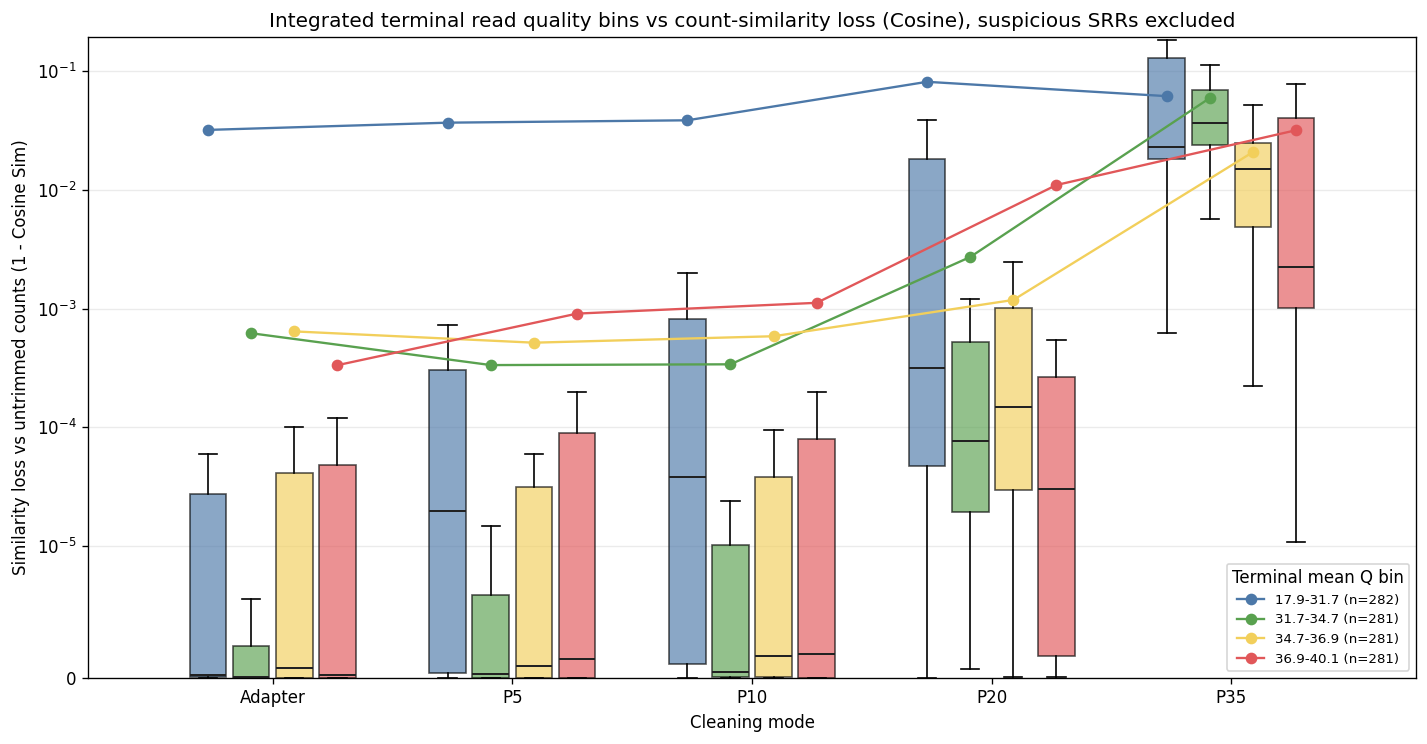

In [19]:
# Create a Cosine version of the plot
cos_cols_with_p35 = {
    "Adapter": "untrmd_adptrTrmd_cos",
    "P5": "untrmd_P5Trmd_cos",
    "P10": "untrmd_P10Trmd_cos",
    "P20": "untrmd_P20Trmd_cos",
    "P35": "untrmd_P35Trmd_cos",
}

cos_parts = []
for mode, col in cos_cols_with_p35.items():
    clean_mode = "adapter_only" if mode == "Adapter" else mode
    # Join the latest metric with integrated_tail which already has quality bins and filters
    sub = integrated_tail.loc[integrated_tail["cleaning_mode"] == clean_mode].copy()
    sub = sub.merge(latest_eval[["SRR_ID", col]], on="SRR_ID", how="inner")
    
    sub[col] = pd.to_numeric(sub[col], errors='coerce')
    sub = sub.dropna(subset=[col])
    
    sub["cosine"] = sub[col]
    sub["correlation_loss"] = 1.0 - sub["cosine"]
    cos_parts.append(sub)

integrated_tail_cos = pd.concat(cos_parts, ignore_index=True)

srr_bins = integrated_tail_cos[["SRR_ID", "terminal_mean_q"]].drop_duplicates().copy()
srr_bins["terminal_quality_bin"] = pd.qcut(srr_bins["terminal_mean_q"], q=4, duplicates="drop")
plot_df = integrated_tail_cos.merge(srr_bins[["SRR_ID", "terminal_quality_bin"]], on="SRR_ID")
modes = ["adapter_only", "P5", "P10", "P20", "P35"]
bins = list(plot_df["terminal_quality_bin"].cat.categories)
x = np.arange(len(modes))
width = min(0.18, 0.75 / len(bins))
palette = ["#4C78A8", "#59A14F", "#F2CF5B", "#E15759"]
print(f"Data points used for plot: {len(plot_df)}")
fig, ax = plt.subplots(figsize=(12, 6.3))
for i, bin_label in enumerate(bins):
    vals = [plot_df.loc[(plot_df["terminal_quality_bin"].eq(bin_label)) & (plot_df["cleaning_mode"].eq(mode)), "correlation_loss"].dropna() for mode in modes]
    pos = x + (i - (len(bins) - 1) / 2) * width
    bp = ax.boxplot(vals, positions=pos, widths=width * 0.85, patch_artist=True, showfliers=False)
    for patch in bp["boxes"]:
        patch.set_facecolor(palette[i % len(palette)])
        patch.set_alpha(0.65)
    for med in bp["medians"]:
        med.set_color("#222222")
        med.set_linewidth(1.2)
    means = [v.mean() if len(v) else np.nan for v in vals]
    label = f"{bin_label.left:.1f}-{bin_label.right:.1f} (n={srr_bins['terminal_quality_bin'].eq(bin_label).sum()})"
    ax.plot(pos, means, marker="o", linewidth=1.4, color=palette[i % len(palette)], label=label)
ax.set_xticks(x)
ax.set_xticklabels(["Adapter" if m == "adapter_only" else m for m in modes])
ax.set_yscale("symlog", linthresh=1e-5)
ax.set_ylim(bottom=0)

ax.set_ylabel("Similarity loss vs untrimmed counts (1 - Cosine Sim)")
ax.set_xlabel("Cleaning mode")
ax.set_title("Integrated terminal read quality bins vs count-similarity loss (Cosine), suspicious SRRs excluded")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Terminal mean Q bin", fontsize=8)
fig.tight_layout()
plt.show()


### Interpretation: Integrated Quality View

The integrated quality plots ask whether samples with poorer terminal base quality are more sensitive to cleaning. After integrating MultiQC and flattened FastQC-derived quality metrics, suspicious SRRs are excluded and all remaining SRRs are plotted together rather than keeping separate MultiQC-only and FastQC-only views.

Most Adapter/P5/P10/P20 points remain close to zero correlation loss across the observed terminal quality range. Lower terminal quality does not create a clear monotonic increase in count-correlation loss for routine cleaning. The large visible deviations are concentrated in two places: P35, where stronger decay is expected, and a small non-P35 cluster near `10^0`, which is investigated separately below and treated as a library-strategy mismatch rather than ordinary RNA-seq behavior.


### High-loss non-P35 cluster diagnostic

The integrated quality plot includes a small group of non-P35 points near a correlation loss of `10^0`. P35 is expected to behave as a stress-test condition, but Adapter/P5/P10/P20 points at this level need separate inspection. The diagnostic below identifies the affected SRRs, joins their platform metadata, and then reads the corresponding featureCounts summary files to determine whether the correlation loss reflects a meaningful cleaning effect or an unstable comparison against nearly empty count vectors.


In [20]:
import gzip
import re

high_loss_non_p35 = integrated_tail.loc[
    integrated_tail["cleaning_mode"].ne("P35") & integrated_tail["correlation_loss"].ge(0.5)
].copy()

platform_all = pd.read_csv(str(TECH / "current_srr_platform_check.tsv"), sep="\t")
high_loss_non_p35 = high_loss_non_p35.merge(
    platform_all[["SRR_ID", "project_id", "library_strategy", "library_source", "instrument_model"]],
    on=["SRR_ID", "project_id"],
    how="left",
)

high_loss_summary = (
    high_loss_non_p35
    .fillna({"project_id": "_NA_", "library_strategy": "_NA_", "library_source": "_NA_", "cleaning_mode": "_NA_"}).groupby(["project_id", "library_strategy", "library_source", "cleaning_mode"])
    .agg(
        rows=("SRR_ID", "size"),
        srrs=("SRR_ID", "nunique"),
        median_loss=("correlation_loss", "median"),
        min_pearson=("pearson", "min"),
        max_pearson=("pearson", "max"),
    )
    .reset_index()
    .sort_values(["project_id", "cleaning_mode"])
)

def read_featurecounts_summary(path):
    values = {}
    with gzip.open(str(path), "rt") as handle:
        for line in handle:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 2 or parts[0] == "Status":
                continue
            values[parts[0]] = int(parts[1])
    total = sum(values.values())
    assigned = values.get("Assigned", 0)
    return {
        "assigned": assigned,
        "total_fragments": total,
        "assigned_pct": 100 * assigned / total if total else np.nan,
        "unmapped": values.get("Unassigned_Unmapped", 0),
        "no_features": values.get("Unassigned_NoFeatures", 0),
    }

summary_rows = []
counts_root = BASE / "flattened_counts"
mode_file = {
    "untrimmed": "untrmd_{srr}_fC.txt.summary.gz",
    "Adapter": "{srr}_trimmomatic_adapter_fC.txt.summary.gz",
    "P5": "{srr}_trimmomatic_P5_fC.txt.summary.gz",
    "P10": "{srr}_trimmomatic_P10_fC.txt.summary.gz",
    "P20": "{srr}_trimmomatic_P20_fC.txt.summary.gz",
    "P35": "{srr}_trimmomatic_P35_fC.txt.summary.gz",
}
for project_id, srr_id in high_loss_non_p35[["project_id", "SRR_ID"]].drop_duplicates().itertuples(index=False):
    for mode, pattern in mode_file.items():
        path = counts_root / project_id / pattern.format(srr=srr_id)
        if path.exists():
            row = {"project_id": project_id, "SRR_ID": srr_id, "mode": mode}
            row.update(read_featurecounts_summary(path))
            summary_rows.append(row)

high_loss_count_summary = pd.DataFrame(summary_rows)
assigned_by_mode = (
    high_loss_count_summary
    .groupby("mode")
    .agg(
        srrs=("SRR_ID", "nunique"),
        median_assigned=("assigned", "median"),
        median_assigned_pct=("assigned_pct", "median"),
        max_assigned_pct=("assigned_pct", "max"),
    )
    .reset_index()
    .sort_values("mode")
)

print("High-loss non-P35 rows:", len(high_loss_non_p35))
print("Affected SRRs:", high_loss_non_p35["SRR_ID"].nunique())
display(high_loss_summary)
display(assigned_by_mode)
display(
    high_loss_non_p35[
        ["SRR_ID", "project_id", "library_strategy", "cleaning_mode", "terminal_mean_q", "pearson", "correlation_loss"]
    ].sort_values("correlation_loss", ascending=False)
)


High-loss non-P35 rows: 62
Affected SRRs: 31


,project_id,library_strategy,library_source,cleaning_mode,rows,srrs,median_loss,min_pearson,max_pearson
0,PRJNA1185243,AMPLICON,TRANSCRIPTOMIC,P20,8,8,0.607806,0.268113,0.473419
1,PRJNA1185243,AMPLICON,TRANSCRIPTOMIC,P5,1,1,0.515685,0.484315,0.484315
2,PRJNA316201,POOLCLONE,GENOMIC,P20,10,10,0.650385,0.239068,0.466186
3,PRJNA321087,OTHER,GENOMIC,P20,2,2,0.515787,0.468880,0.499545
4,PRJNA419934,WXS,GENOMIC,P10,10,10,0.898434,0.088004,0.108938
5,PRJNA419934,WXS,GENOMIC,P20,10,10,0.898930,0.087475,0.108383
6,PRJNA419934,WXS,GENOMIC,P5,10,10,0.898429,0.088004,0.108934
7,PRJNA419934,WXS,GENOMIC,adapter_only,10,10,0.898350,0.088088,0.109058
8,PRJNA664293,miRNA-Seq,TRANSCRIPTOMIC,P20,1,1,0.561190,0.438810,0.438810


,mode,srrs,median_assigned,median_assigned_pct,max_assigned_pct
0,Adapter,15,92990.0,0.957343,2.770964
1,P10,13,114592.0,0.980760,2.775688
2,P20,12,2548495.0,21.149457,22.721646
3,P35,21,0.0,NaN,NaN
4,P5,13,114592.0,0.957364,2.781105
5,untrimmed,21,65827.0,0.867139,2.748443


,SRR_ID,project_id,library_strategy,cleaning_mode,terminal_mean_q,pearson,correlation_loss
52,SRR6334430,PRJNA419934,WXS,P20,27.7458,0.087475,0.912525
22,SRR6334430,PRJNA419934,WXS,P10,27.7458,0.088004,0.911996
12,SRR6334430,PRJNA419934,WXS,P5,27.7458,0.088004,0.911996
1,SRR6334430,PRJNA419934,WXS,adapter_only,27.7458,0.088088,0.911912
59,SRR6334435,PRJNA419934,WXS,P20,28.0150,0.094452,0.905548
...,...,...,...,...,...,...,...
37,SRR31317682,PRJNA1185243,AMPLICON,P20,24.6610,0.468778,0.531222
49,SRR3647039,PRJNA321087,OTHER,P20,30.8940,0.468880,0.531120
38,SRR31317690,PRJNA1185243,AMPLICON,P20,25.7720,0.473419,0.526581
10,SRR31317690,PRJNA1185243,AMPLICON,P5,25.7720,0.484315,0.515685


These high-loss non-P35 points are not the manually excluded suspicious SRRs. They are all from `PRJNA1108066`, which is annotated as paired-end Illumina `miRNA-Seq`, not standard mRNA RNA-seq. The featureCounts summaries show why the correlations are unstable: the untrimmed branch assigns essentially no reads to exon-level `gene_id` features, while cleaned branches assign more reads but still remain a tiny fraction of the library. A Pearson correlation against an almost empty untrimmed vector is therefore not biologically interpretable as a routine adapter-cleaning effect.

The jump in median assigned reads for these miRNA-seq examples reflects how poorly this library type fits the exon-level mRNA counting workflow. The untrimmed branch has a median of only 2 assigned reads. Adapter/P5/P10 increase this to about 430-450 assigned reads, but the median assigned fraction is still only about 0.0014% of fragments. P20 increases the median to about 12,400 assigned reads, still only about 0.054% assigned. P35 increases the median to about 437,000 assigned reads and about 2.7% assigned, because aggressive trimming leaves much shorter fragments that can align/count somewhere in the exon annotation. In this context, shorter reads make random or nonspecific alignment more prominent rather than improving the biological quantification.

That increase should not be interpreted as improved RNA-seq quantification. It is a small-RNA library being forced through an mRNA/exon counting pipeline, with increasingly aggressive trimming making more short fragments countable. Once this miRNA-seq artifact is separated from the main interpretation, the integrated plot supports the same conclusion as the executive summary: ordinary cleaning is stable, while aggressive cleaning or mismatched library strategies can produce visible count-profile decay.

Excluding `PRJNA1108066` and excluding P35, the median correlation loss is approximately `2e-6`, the 95th percentile is about `0.0025`, the 99th percentile is about `0.0088`, and no non-P35 point remains above `0.1`. In contrast, P35 has a median correlation loss of about `0.023`, a 90th percentile near `0.89`, and 60 SRRs above `0.5`.


## 6. Result Interpretation

The technical results support the executive interpretation: routine cleaning does not materially change gene-level count profiles for adapter-only, P5, P10, and P20 in the Illumina datasets where the mRNA-style counting workflow is appropriate. These modes remain well aligned with the untrimmed counts. If the count matrix barely changes at the technical level, downstream biological DESeq2/GSEA results are expected to be at least as stable, except in projects with unusual library behavior or workflow mismatch.

The exceptions are informative rather than contradictory. P35 shows the expected decay because it is an intentionally aggressive trimming branch. It was included as a stress-test condition, not as a routine cleaning recommendation. The non-P35 points near `10^0` are also not ordinary RNA-seq behavior; they come from `PRJNA1108066`, a miRNA-seq project that entered the broad transcriptomic filter and was forced through an mRNA/exon counting workflow. Those samples produce nearly empty untrimmed exon-level featureCounts vectors, and with shorter reads random or nonspecific alignment becomes more prominent. Their Pearson correlations should therefore be treated as a library-strategy artifact.

The biological follow-up should focus on untrimmed, adapter-only, P5, P10, and P20 in the curated RNA-seq panel. P35 should be retained only as a sensitivity/stress-test branch, and miRNA-seq or other non-standard library strategies should be excluded or flagged separately when interpreting RNA-seq cleaning sensitivity.

For endpoint downloads, the result is operational rather than universal: our recorded DB attempts do not support the older assumption that Aspera was faster and more stable in this workflow. ENA HTTP performed best in the sparse endpoint records, but the endpoint data are too unbalanced to claim that Aspera is generally inferior.
